## Import Bertie's magic toolbox
All information about PyNekTools can be found:

https://github.com/ExtremeFLOW/pyNekTools

If you don't have access you can contact Bertie, but if you have access to `neko` you should have access to this.

In [1]:
# Import required modules
from mpi4py import MPI #equivalent to the use of MPI_init() in C
import matplotlib.pyplot as plt
import numpy as np

# Get mpi info
comm = MPI.COMM_WORLD

# Hide the log for the notebook. Not recommended when running in clusters as it is better you see what happens
import os
os.environ["PYNEKTOOLS_HIDE_LOG"] = 'true'

from pynektools.io.ppymech.neksuite import pynekread
from pynektools.datatypes.msh import Mesh
from pynektools.datatypes.coef import Coef
from pynektools.datatypes.field import FieldRegistry
from pynektools.postprocessing.file_indexing import index_files_from_folder

## Read the statistics fields
The idea here is that we have already accumulated certain statistics using the statistics toolbox in `neko`.

We only really care about mean fields right now, but for the full documentation of the statistics output file see:

https://neko.cfd/docs/develop/df/d8f/statistics-guide.html

If everything goes well with Tim's script we should have a `fluid_stats0/` folder floating around somewhere.

In [25]:
results_path = "../../../results/brinkman_parameters/dt_check/"
Brinkman_path = "brinkman/"
meshed_path = "meshed/"
stats_file = "field0"

brinkman_msh = Mesh(comm, create_connectivity=True)
brinkman_fld = FieldRegistry(comm)
meshed_msh = Mesh(comm, create_connectivity=True)
meshed_fld = FieldRegistry(comm)

# remember the mesh is only stored in the first one!
# here we're just getting the mesh
fname = results_path + Brinkman_path + stats_file + '/' + stats_file +'.f00000'
pynekread(fname, comm, data_dtype=np.double, msh=brinkman_msh)
pynekread(results_path + meshed_path + stats_file + '/' + stats_file +'.f00000', comm, data_dtype=np.double, msh=meshed_msh)

# TODO
# Right now I'm just playing around with one, but ultimately we will take an "average of the averages"
pynekread(results_path + Brinkman_path + stats_file + '/' + stats_file +'.f00001', comm, data_dtype=np.double, fld=brinkman_fld)
pynekread(results_path + meshed_path + stats_file + '/' + stats_file +'.f00001', comm, data_dtype=np.double, fld=meshed_fld)

### Plot the 2D velocity field
This isn't necessary, I was just checking that it works. These tools are so nice!!

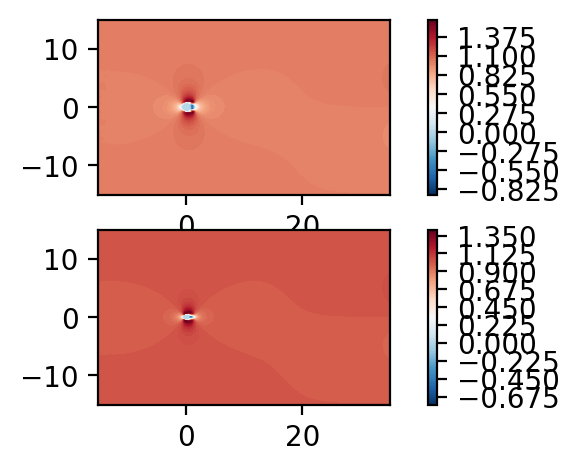

In [29]:
fig, ax = plt.subplots(2,1, figsize=(5, 2.5), dpi = 200)
c = ax[0].tricontourf(brinkman_msh.x.flatten(), brinkman_msh.y.flatten() ,brinkman_fld.registry["u"].flatten(), levels=100, cmap="RdBu_r")
fig.colorbar(c)
ax[0].set_aspect('equal')
c = ax[1].tricontourf(meshed_msh.x.flatten(), meshed_msh.y.flatten() ,meshed_fld.registry["u"].flatten(), levels=100, cmap="RdBu_r")
fig.colorbar(c)
ax[1].set_aspect('equal')
plt.show()

## Wake lines

We should inspect the wake (of the averaged fields) and some downstream locations.
Right now I'm just plotting them all on the same plot. But I guess what would be more useful is to plot different cases

In [34]:
from pynektools.interpolation.probes import Probes
import pynektools.interpolation.utils as interp_utils
import pynektools.interpolation.pointclouds as pcs

# All wake size/resolution
y_lims = [-15, 15]
n_pts = 50

if comm.Get_rank() == 0 :
    # Wake line
    y_1d = pcs.generate_1d_arrays(y_lims, n_pts, mode="equal")
    x_1d = [10]
    z_1d = [0.5]
    x, y, z = np.meshgrid(x_1d, y_1d, z_1d, indexing='ij')
    # Write the points for future use
    xyz = interp_utils.transform_from_array_to_list(1,n_pts,1,[x, y, z])
else:
    xyz = None


# This sets up the probes interpolation
brinkman_probes = Probes(comm, probes = xyz, msh = brinkman_msh, point_interpolator_type='multiple_point_legendre_numpy', max_pts=256, find_points_comm_pattern='point_to_point')
meshed_probes = Probes(comm, probes = xyz, msh = meshed_msh, point_interpolator_type='multiple_point_legendre_numpy', max_pts=256, find_points_comm_pattern='point_to_point')
# here we actually probe
brinkman_probes.interpolate_from_field_list(0, [brinkman_fld.registry['u']], comm, write_data=False)
meshed_probes.interpolate_from_field_list(0, [meshed_fld.registry['u']], comm, write_data=False)

## Now we actually plot them!

I'm just doing one as an example

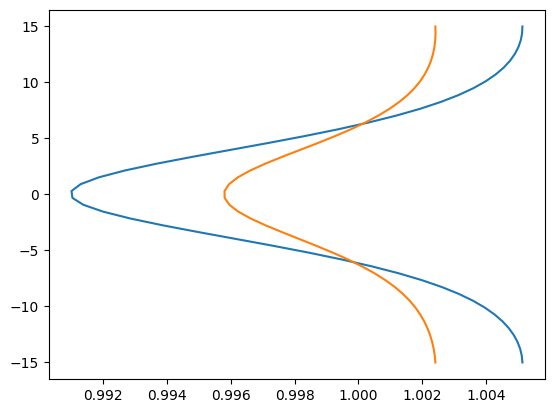

In [35]:
plt.plot(brinkman_probes.interpolated_fields[:,1], y_1d)
plt.plot(meshed_probes.interpolated_fields[:,1], y_1d)
plt.show()